# Lab 2 &mdash; Fourier transform

## Submission rules:

1. The completed assignment should be prepared as s a Jupyter Notebook (.ipynb file) downloaded from your team's Google Colab. Make sure you made a copy of the notebook above and opened it via UCU email address. Submit the Jupyter Notebook (.ipynb file) to **cms**.
2. There should be only one submission per team. However, don't forget to choose a person from your team who would submit the task, and make sure that the names of all team members are listed in the notebook. Teammates not mentioned in the notebook will not be graded for this lab.
3. This time, you also need to provide a **work breakdown structure** estimating the efforts of each team member. Please provide it at the top of your notebook.
4. This lab requires some visualization from you; please arrange it accordisamples_numg to best practices (appropriate axes labels, title, size/scale are a minimum).
5. The final deadline is **March 17 2025, 23:59**. Making any changes to your code after this time and date is forbidden and will be a reason for point deduction for the whole team.

#### Work breakdown (example):

Kukurudza Viktoria: Analyzing a song (3, 5).

Krasniukevych Mariia: Working with an example audio, sinusoids.

Lyhanskiy Oleksandr: Analyzing a song (4, 6).

Myhailyschuk Nazar: Analyzing a song (1, 2).


## Introduction
Soon, you will learn about Fourier transform, i.e., an operator that maps functions depending on space (resp. time) variables into functions depending on spatial (resp. temporal) frequency, which is widely used in spectroscopy and signal processing.  

One of the motivations to use Fourier transform comes from the study of Fourier series. In our particular case, you will transform sound (a continuous wave that is a mixture of multiple frequencies) into an arrray of pure frequencies that can be analyzed with the help of Discrete Fourier Transform. The ultimate goal is to decompose a melody into a sequence of pitches and then to notes (without any help of a trained musician's ear &mdash; that would be cheating!).

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from IPython.display import Audio
%matplotlib inline

## Sinusoids

Let's first consider a simple example. Decompose a series sin3 that is a sum of two sinusoids using the Fast Fourier transform from scipy library. FFT is simply a computationally efficient implementation of a discrete Fourier transform. What is the frequency of sin1 and sin2 signals?

sin1 - $\frac{1}{2\pi}$

sin2 - $\frac{5}{2\pi}$


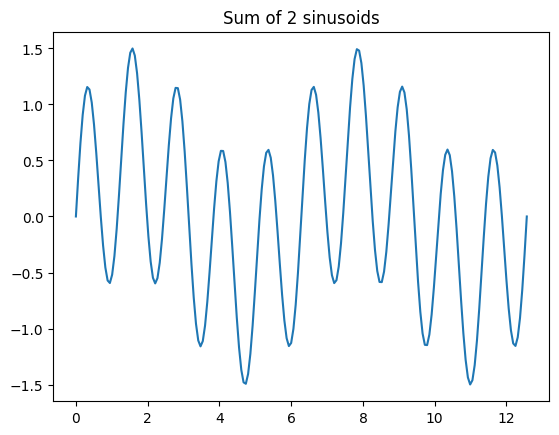

In [2]:
x = np.linspace(0, 4*np.pi, 200)
sin1 = 0.5 * np.sin(x)
sin2 = np.sin(5*x)
sin3 = sin1 + sin2
plt.plot(x, sin3)
plt.title('Sum of 2 sinusoids')
plt.show()


Apply FFT to sin3 series to obtain frequency decomposition and plot the results.

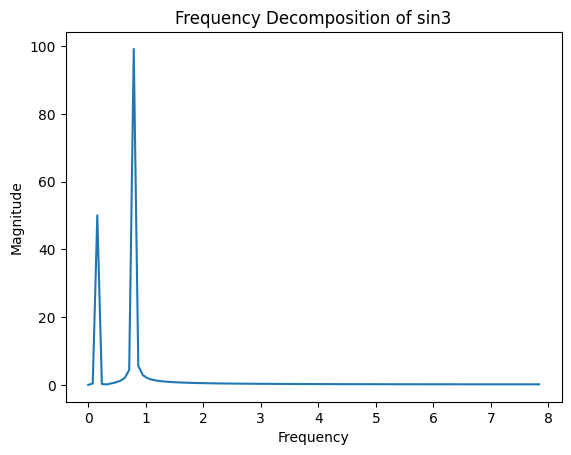

In [3]:
fft_values = np.fft.fft(sin3)
dist = x[1] - x[0]
frequencies = np.fft.fftfreq(len(sin3), d=dist)
magnitude = np.abs(fft_values)
half = len(sin3) // 2

plt.plot(frequencies[:half], magnitude[:half])
plt.title('Frequency Decomposition of sin3')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.show()

Make sure that you got 2 spikes corresponding to the frequencies that we assigned to the sinusoids earlier. Explain how the transformation is conducted and why we can obtain two perfectly separated frequencies from a mixed signal.



The signal is a vector expressed as a linear combination of sinusoids of different frequencies. The Fourier transform performs a change of basis from the time domain to the frequency domain. Since the Fourier basis functions are orthogonal, projecting the signal onto each basis vector isolates the corresponding frequency component. Therefore, the mixed signal produces two distinct spikes in the frequency domain, corresponding to the two original sinusoids.

## Working with example audio

Now, let's work with a more complex wave&mdash;sound. Any sound (audio signal) can be characterized by the following three quantities: Pitch, Quality, and Loudness.

Loudness is a physiological sensation that depends mainly on the sound wave pressure (amplitude).

The lowest note in a chord is called fundamental. It is heard predominantly due to larger intensity. Quality is determined by overtones or harmonics that add to the sound of a fundamental note.

Pitch is the frequency of a sound as perceived by human ear. A high frequency gives rise to a high pitch note and a low frequency produces a low pitch note. A pure tone is the sound of only one frequency, such as that given by a tuning fork or electronic signal generator. Naturally, music does not consist of pure tones. Depending on an instrument, technique and many other factors, sound will decay at different rates and one tone will mix with the other ones.

Thus, transcribing audio files into standard music notation (i.e., the notes) is a non-trivial task. We will focus on recognizing pitches and matching them to notes.

### Load and explore

In [4]:
# Load first sound from library examples
# Monophonic trumpet recording
trumpet_path = librosa.example('trumpet')
Audio(trumpet_path)

In [5]:
trumpet_sample, trumpet_sampling_rate = librosa.load(trumpet_path)
trumpet_sampling_rate

22050

What is a sampling rate? What does sampling rate imply about the audio? Is it sufficient for our task (according to https://en.wikipedia.org/wiki/Nyquist%E2%80%93Shannon_sampling_theorem)?


---
The sampling rate is the number of samples of an audio signal taken per second. It determines the maximum frequency that can be accurately represented in the signal.
According to the Nyquist-Shannon sampling theorem frequencies above 11,025 Hz in our audio cannot be correctly captured. It is sufficient for our task because the trumpet signal mainly contains frequencies below 1000 Hz

---

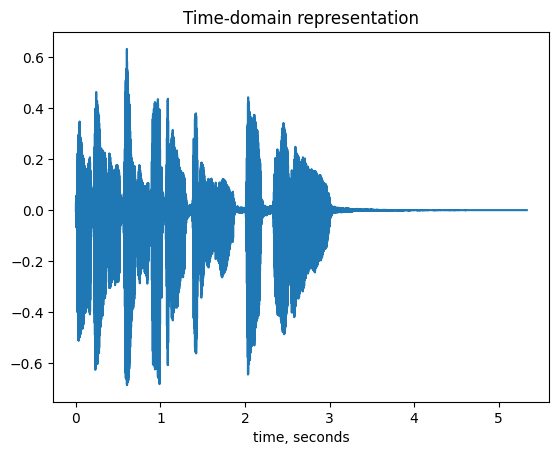

In [6]:
# Initial visualization
time = np.array(range(trumpet_sample.shape[0])) / trumpet_sampling_rate
plt.plot(time, trumpet_sample)
plt.title('Time-domain representation')
plt.xlabel('time, seconds')
plt.show()

This visualization is called the time-domain representation of a given signal. This shows us the loudness (amplitude) of sound wave changing with time. Here amplitude = 0 represents silence. These amplitudes are not very informative as they only represent the loudness of audio recording. To better understand the audio signal, it is necessary to transform it into the frequency domain. The frequency-domain representation of a signal tells us which frequencies are present in the signal.

Decompose the trumpet samples using fft and plot the results. Observe that the frequency pattern corresponds to the pitch changes.

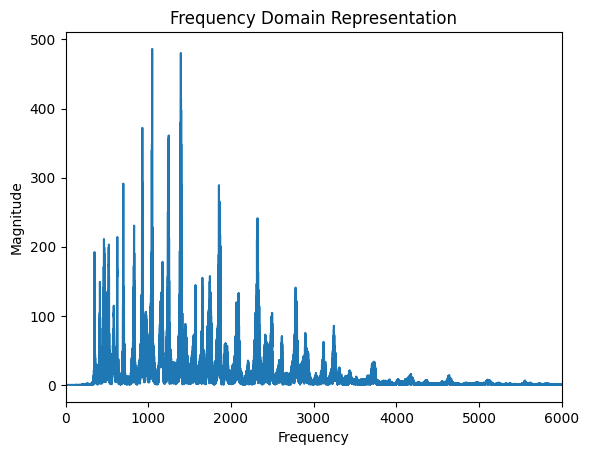

In [7]:
fft_values = np.fft.fft(trumpet_sample)
frequencies = np.fft.fftfreq(len(trumpet_sample), d=1/trumpet_sampling_rate)
magnitude = np.abs(fft_values)
half = len(trumpet_sample) // 2

plt.plot(frequencies[:half], magnitude[:half])
plt.title('Frequency Domain Representation')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.xlim(0, 6000)
plt.show()

## Analyzing a song

In the next task, you need to use the recording of a famous Ukrainian song (piano_melody.mp3) attached on cms. Your creativity is not limited here so any better ways to compelling visuals, more advanced algorithms on top of FFT or spectrogram, and explanations will be rewarded.     


1.   Load the recording, replay it, and plot in the time domain. To get a better view of how the notes change throughout a shorter time, choose a sample of the audio up to 5 seconds and plot it in the time domain. From here on out you will be working with this smaller 5-second sample.


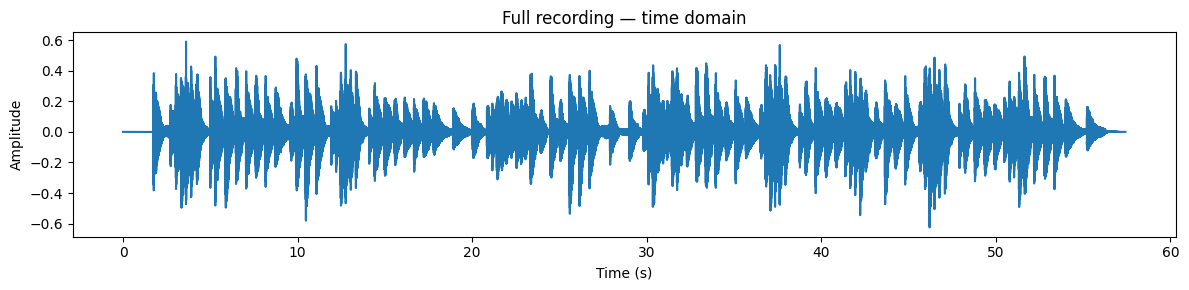

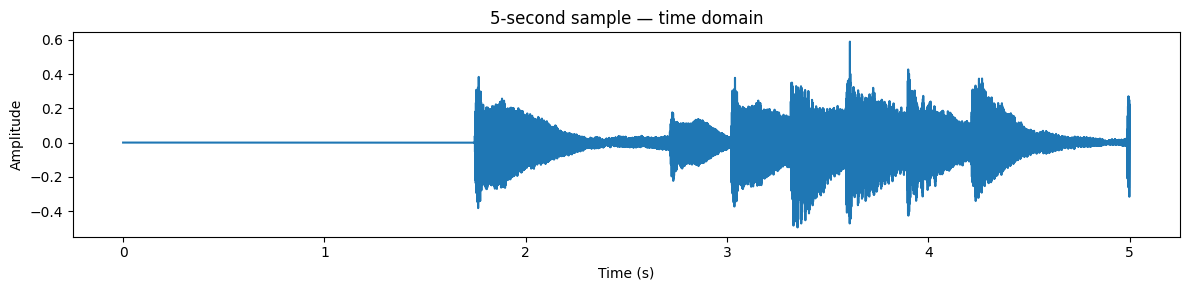

In [8]:
# Loading sound
path = 'melody/piano_melody.mp3'
samples, sampling_rate = librosa.load(path)
display(Audio(path))

# Plot full recording in time domain
time_full = np.arange(len(samples)) / sampling_rate
plt.figure(figsize=(12, 3))
plt.plot(time_full, samples)
plt.title('Full recording — time domain')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

# Creating a 5-second sample of the audio
n_samples_5s = 5 * sampling_rate
samples = samples[:n_samples_5s]

# Plot 5-second sample in time domain
time_5s = np.arange(len(samples)) / sampling_rate
plt.figure(figsize=(12, 3))
plt.plot(time_5s, samples)
plt.title('5-second sample — time domain')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()


2.   Build a spectrogram of the sample. Explain what domain the spectrogram represents us and how can it be useful.


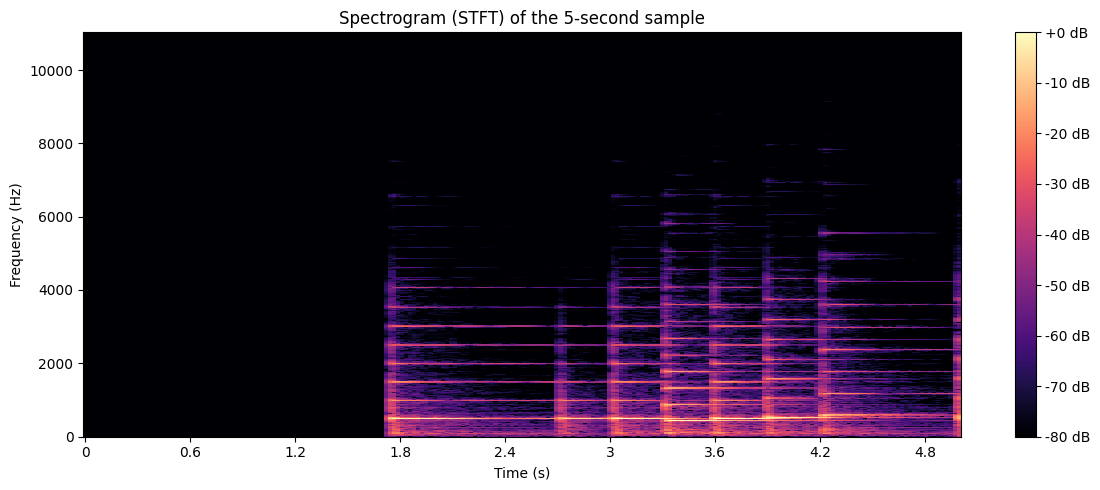

In [9]:
# Spectrogram of the 5-second sample
D = librosa.stft(samples)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12, 5))
librosa.display.specshow(S_db, sr=sampling_rate, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram (STFT) of the 5-second sample')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.tight_layout()
plt.show()


---
> **Explanation:**
>
> A spectrogram represents the **time-frequency domain**: it shows how the frequency content of a signal evolves over time. The horizontal axis is time, the vertical axis is frequency (Hz), and the colour intensity encodes amplitude (in dB).
>
> It is computed via the **Short-Time Fourier Transform (STFT)**, which applies FFT to short overlapping windows of the signal. This gives us both *when* a frequency is present and *how strongly*, unlike a plain FFT which collapses all time information.
>
> For audio analysis this is very useful: we can see which notes (fundamental frequencies) are played at each moment, observe their overtones/harmonics above them, and track how the sound energy decays between notes — all at a glance.

---

3.   Transform signal to the frequency domain with FFT and study the distribution of pitches (frequencies).
Observe that the melody contains only a couple of distinct sounds, but there are a lot more spikes in the frequency domain.

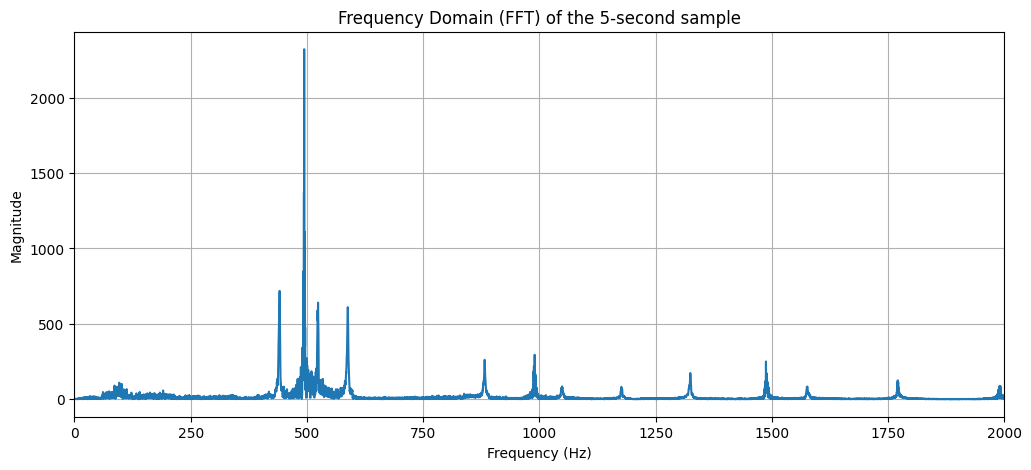

In [10]:
fft_spectrum = np.fft.fft(samples)
amplitude = np.abs(fft_spectrum)

frequencies = np.fft.fftfreq(len(samples), d=1/sampling_rate)

half_n = len(samples) // 2
plt.figure(figsize=(12, 5))
plt.plot(frequencies[:half_n], amplitude[:half_n])

plt.title('Frequency Domain (FFT) of the 5-second sample')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, 2000)
plt.grid(True)
plt.show()

4. Apply averaging to the initial signal. Averaging is a procedure that reduces number of samples by taking mean of each n of our samples. Experiment with n and determine whichever will work best to both reduce the noise and not loose any information. You can propose other ways to efficiently denoise the signal.

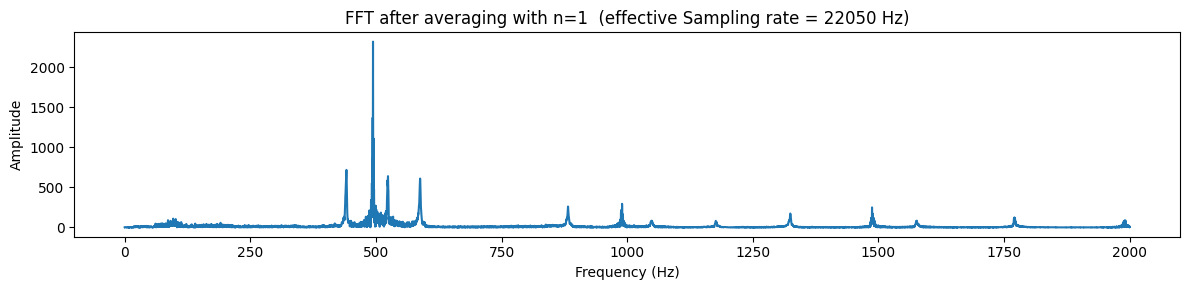

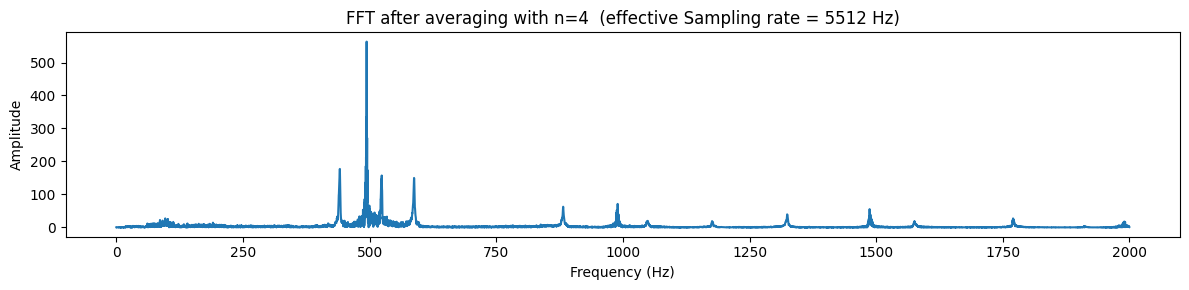

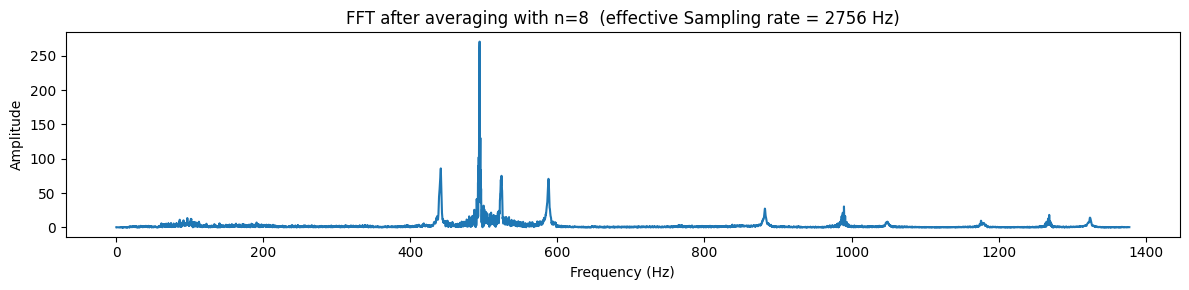

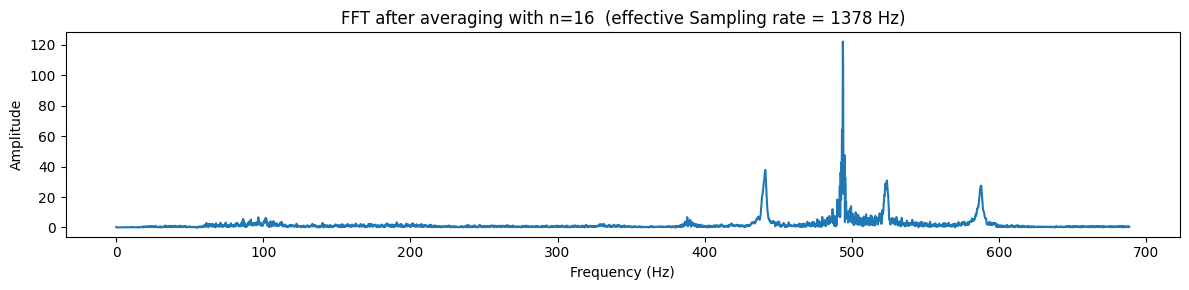

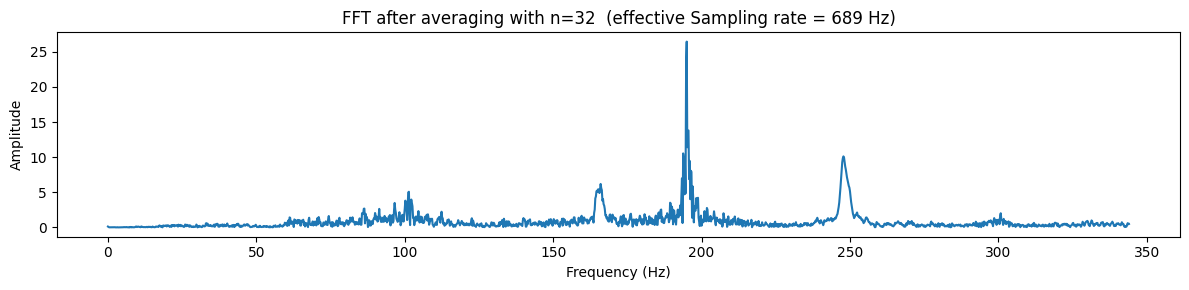

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def plot_fft(signal, sampling_rate, title, max_freq=2000):
    '''
    This is a worker function to plot FFT transformation
    '''
    samples_num = len(signal)
    f = fftfreq(samples_num, d = 1 / sampling_rate)                               # all the frequencies
    ampl = np.abs(fft(signal))                                                    # all the amplitudes

    criteria = (f >= 0) & (f <= max_freq)
    plt.figure(figsize=(12, 3))
    plt.plot(f[criteria], ampl[criteria])
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()

def average_signal(signal, n):
    '''
    This is a worker function to Average the signal.
    Basically to take only certain intervals of it and
    find the mean. Further those means are glued together.
    That gives us an result signal.
    The bigger n (number of samples in the interval we get)
    the less accurate result we obtain. Though often
    it is better to get a less accurate result rather than
    the original one with all the noise interfering with the signal.
    '''
    
    trim = signal[:len(signal) - len(signal) % n]                       # take only the interval that is divisible by n

    return trim.reshape(-1, n).mean(axis=1)                             # transform the array into matrix and take the mean by rows
                                                                        # -1 arg in reshape method says that the dimension is known
                                                                        # and will be derived on a go
                                                                        # we are transforming the array into k x n matrix

factor_values = [1, 4, 8, 16, 32]

for n in factor_values:
    result = average_signal(samples, n)
    upd_sr   = sampling_rate // n
    plot_fft(
        result, upd_sr,
        title=f'FFT after averaging with n={n}  (effective Sampling rate = {upd_sr} Hz)',
        max_freq=min(2000, upd_sr // 2))

---
Conclusion
-----------

**Other ways to denoise a signal**

To denoise a signal a low-pass filter could be used. It effectively reduces the impact of high-frequency signals, though for signals that have frequency close enough to the cut-off frequency of the filter the impact of filtering might be insufficient due to the logariphmic amplitude characteristic of a filter.

Results:
* n = 1  : The signal wasn't changed. High-frequency noise impact can be clearly seen
* n = 4  : Smoothes the signal a little bit. We can still see the high-frequency pitches
* n = 8  : Solid choice. The signal is mostly preserved. High frequencies above 1kHz still can be seen.
* n = 16 : Smoothes the original signal even further. High frequencies above 1kHz are blured.
           This option is not bad, though we loose a significant part of the original signal.
* n = 32 : That's evidently an overkill. Such drastic averaging deprieves the original signal not only of the high frequencies but also of some relatively low-frequency harmonics such as 400 - 700 Hz. Better to avoid.

The best choice is n = 8:
  Effective Sampling Rate = sampling_rate / 8 ≈ 2756 Hz
  According to the Nyquist theorem 1378 Hz (2756 / 2) is enough to cover the interval of piano frequencies.
  Piano basic frequencies lie in 261–1047 Hz, so all important pitches are preserved while high-frequency noise is cut.

**Other ways to denoise a signal**

To denoise a signal a low-pass filter could be used. It effectively reduces the impact of high-frequency signals, though for signals that have frequency close enough to the cut-off frequency of the filter the impact of filtering might be insufficient due to the logariphmic amplitude characteristic of a filter.

---

5. Match fundamental pitches you discovered to the standard note frequencies and display them in a table like the one outlined below.

|Detected frequency(Hz) | Assigned frequency(Hz) | Output note|   
|:---------------------:|:----------------------:|:----------:|
|393.2 |391.9| G4  

In [12]:
from scipy.signal import find_peaks

peaks, properties = find_peaks(amplitude[:half_n], height=400, distance=50)

detected_freqs = frequencies[peaks]
detected_magnitudes = properties['peak_heights']

results = []

for freq in detected_freqs:
    note_name = librosa.hz_to_note(freq)
    assigned_freq = librosa.note_to_hz(note_name)
    
    results.append([round(freq, 1), round(assigned_freq, 1), note_name])

print(f"{'Detected frequency (Hz)':<25}  {'Assigned frequency (Hz)':<25}  {'Output note':<12}")

for row in results:
    print(f"{row[0]:<25}  {row[1]:<25}  {row[2]:<12}")

Detected frequency (Hz)    Assigned frequency (Hz)    Output note 
441.4                      440.0                      A4          
494.2                      493.9                      B4          
524.0                      523.3                      C5          
588.0                      587.3                      D5          


In the last task you will use the recording of Lynyrd Skynyrd - Free Bird.

6.    Experiment with filtering of free_bird.mp3 using Butterworth filter (or other ways which you prefer), so that only bass could be heard. (Hint: you can use [scipy.signal.butter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html)). Replay original and filtered audios. Plot their time and frequency domains.

664175 Samples | Sample Rate = 44100 Hz | duration = 15.1 s


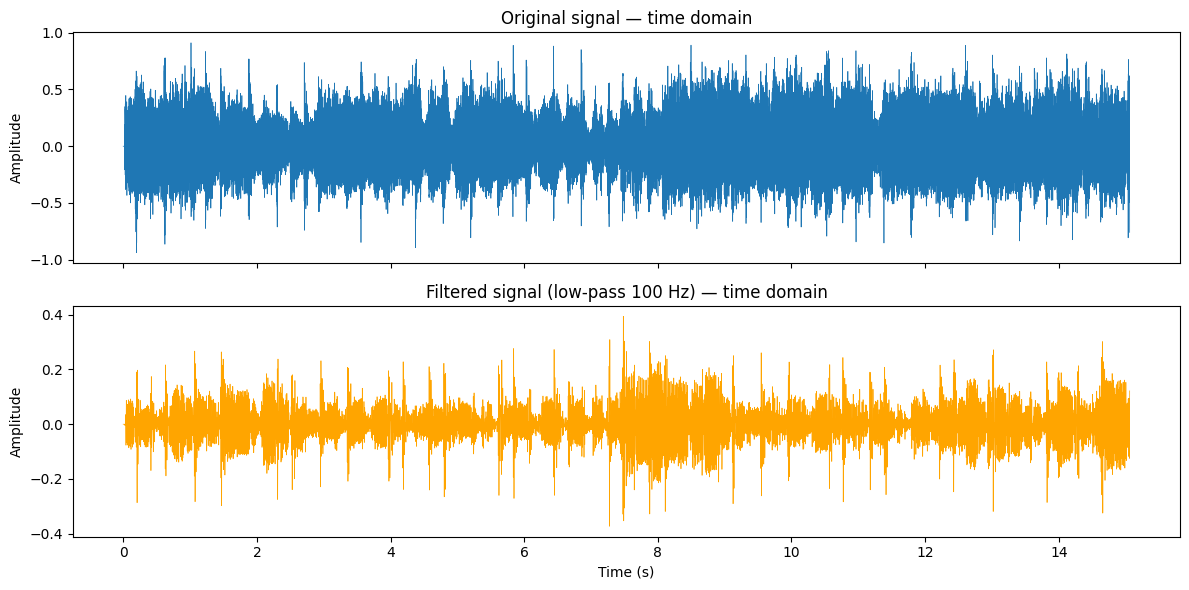

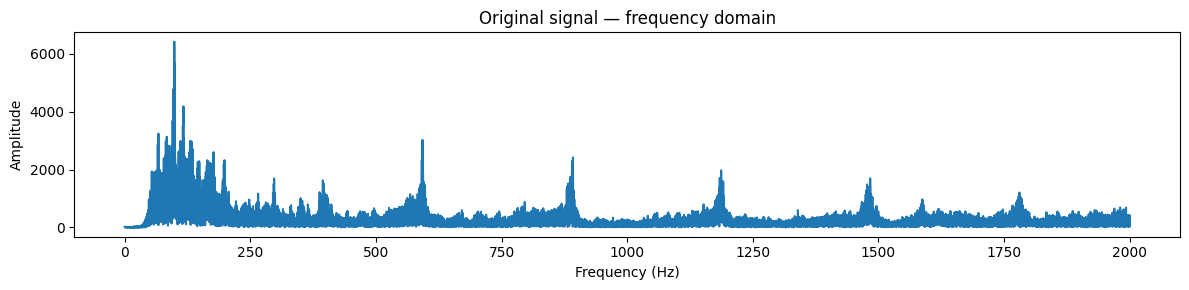

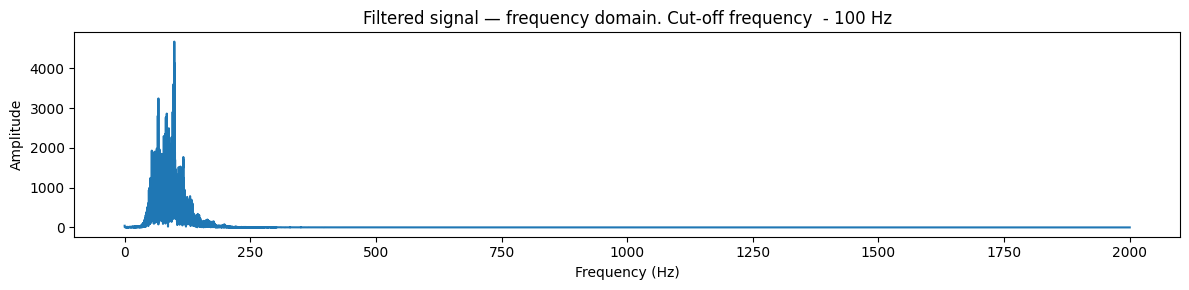

Original:


Filtered signal. Butterworth low-pass filter, cut-off = 100 Hz:


In [13]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import butter, sosfilt
from scipy.fft import fft, fftfreq
from IPython.display import Audio, display

def plot_fft_with_cutoff(signal, sample_rate, title, max_freq=4000):
    '''
    Worker function to plot fft with cutoff frequency.
    '''
    N = len(signal)
    freqs = fftfreq(N, d=1/sample_rate)
    mags  = np.abs(fft(signal))
    mask  = (freqs >= 0) & (freqs <= max_freq)
    plt.figure(figsize=(12, 3))
    plt.plot(freqs[mask], mags[mask])
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.axvline(cut_off_f, color='red', linestyle='--', label=f'Cut-off {cut_off_f} Hz')
    plt.legend()
    plt.tight_layout()
    plt.show()


PATH = './melody/free_bird.mp3'
samples, s_rate = librosa.load(PATH, sr=None, mono=True)

print(f'{len(samples)} Samples | Sample Rate = {s_rate} Hz |' f' duration = {len(samples)/s_rate:.1f} s')

def LowP_filter(signal, cutoff_hz, sample_rate, order=5):
    '''
    Function taht applies Butterworth filter
    '''
    out = butter(order, cutoff_hz, btype='low', fs=sample_rate, output='sos') # a sequence of filters of lower order instead
                                                                              # of a high-order filter which makes calculations
                                                                              # less accurate  
    return sosfilt(out, signal)


                                                                # According to the internet, Bass freq. lies between 60 - 250 Hz
                                                                # We experiment with freq. values to find the best for our case.
                                                                # In my case I found out that 100 Hz isolates perfectly the bass-guitar.
                                                                # It could sound even better if my dynamics would be a little bit louder.
cut_off_f = 100                                                    
filtered = LowP_filter(samples, cutoff_hz=cut_off_f, sample_rate=s_rate, order=5)

time = np.arange(len(samples)) / s_rate

fig, axes = plt.subplots(2, 1, figsize = (12, 6), sharex=True)
axes[0].plot(time, samples, linewidth = 0.5)
axes[0].set_title('Original signal — time domain')
axes[0].set_ylabel('Amplitude')
axes[1].plot(time, filtered, linewidth=0.5, color='orange')
axes[1].set_title(f'Filtered signal (low-pass {cut_off_f} Hz) — time domain')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

plot_fft(samples, s_rate, 'Original signal — frequency domain')
plot_fft(filtered, s_rate, f'Filtered signal — frequency domain. Cut-off frequency  - {cut_off_f} Hz')

print('Original:')
display(Audio(samples, rate = s_rate))

print('Filtered signal. Butterworth low-pass filter, cut-off =', cut_off_f, 'Hz:')
display(Audio(filtered, rate=s_rate))


---
Conclusion
---
We applied a Butterworth low-pass filter with a cut-off at 100 Hz to isolate the bass frequencies of Free Bird song.

The filter was designed using scipy.signal.butter with order=5 and applied via sosfilt (second-order sections for numerical stability). 5th order gives the most rapid angle of a signal suppression (as a result of number of capacitors in filters schematic).

Bass instruments have frequencies around 60–250 Hz. Thus we chose a cutoff freq to isolate only the bass.

The Butterworth filter was chosen for its maximally flat frequency response in the passband. It is one of the most fast-reacting low-pass filters.

From the plots of frequency domain above we can clearly see that all of the higher frequencies have been suppressed.
Also the Audio of the bass supports our claim of the filter working properly.

## Summary

### 1. What is Fourier transform and how is it used in signal processing?

The Fourier Transform is a mathematical method that decomposes a function or signal into its constituent frequencies.

It is commonly used for:
- spectrum analysis,
- filtering,
- audio compression.

### 2. What are time and frequency domains, and why are they useful?

The time domain represents a signal as it evolves over time: the horizontal axis is time (seconds), and the vertical axis is amplitude.

The frequency domain, obtained via the Fourier Transform, represents the same signal by frequencies: the horizontal axis is frequency (hertz), and the vertical axis shows energy or amplitude at each frequency.

Some problems that are difficult in one domain become straightforward in the other. For example, separating overlapping audio signals is hard in the time domain, but in the frequency domain their spectral components are distinct and can be isolated.

### 3. What is averaging and what is its purpose?

In audio signal processing, averaging means combining multiple recordings or samples of the same sound by computing their mean value.

Its main purpose is to reduce background noise: random noise tends to cancel out across multiple takes, while the actual signal remains consistent and adds up.

This technique is widely used in studio recording and acoustic measurements to extract a clean signal from a noisy environment.